# Aufgabenblatt 4
## Eindimensionale Analysis – Grenzwerte

Alle Grenzwerte werden **algebraisch/analytisch** hergeleitet und anschließend mit `sympy` verifiziert sowie mit `matplotlib` visualisiert.

In [ ]:
#  Imports 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sympy import *

x = symbols('x')

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#0f0f1a',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#ccc',
    'xtick.color':      '#888',
    'ytick.color':      '#888',
    'grid.color':       '#222',
    'grid.linewidth':   0.6,
    'text.color':       '#eee',
    'font.family':      'monospace',
    'figure.dpi':       120,
})

CYAN   = '#00e5ff'
ORANGE = '#ff6e3a'
GREEN  = '#39ff14'
PINK   = '#ff4fcf'

def annotate_limit(ax, px, py, label, color=ORANGE):
    """Markiert den Grenzwertpunkt mit einem offenen Kreis und Beschriftung."""
    ax.plot(px, py, 'o', markersize=9, color=color,
            markerfacecolor='#0f0f1a', markeredgewidth=2, zorder=5)
    ax.annotate(label, xy=(px, py), xytext=(px+0.15, py+0.15),
                color=color, fontsize=10,
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2))

print('Setup fertig ✓')

Setup fertig ✓


---
## Aufgabe 1

$$\lim_{x \to 4} \frac{x-4}{x^2-x-12}$$

### Analytische Lösung

**Schritt 1 – Einsetzen prüfen:**  
Für $x=4$: Zähler $= 4-4 = 0$, Nenner $= 16-4-12 = 0$ → **unbestimmter Ausdruck** $\tfrac{0}{0}$.

**Schritt 2 – Faktorisierung des Nenners:**  
Gesucht sind $a,b$ mit $a+b=-1$ und $a\cdot b=-12$:  
$$x^2 - x - 12 = (x-4)(x+3)$$

**Schritt 3 – Kürzen des gemeinsamen Faktors $(x-4)$:**  
$$\frac{x-4}{(x-4)(x+3)} = \frac{1}{x+3}, \quad x \neq 4$$

**Schritt 4 – Grenzwert berechnen:**  
$$\lim_{x \to 4} \frac{1}{x+3} = \frac{1}{4+3} = \boxed{\dfrac{1}{7}}$$

sympy bestätigt: lim = 1/7  (0.142857)


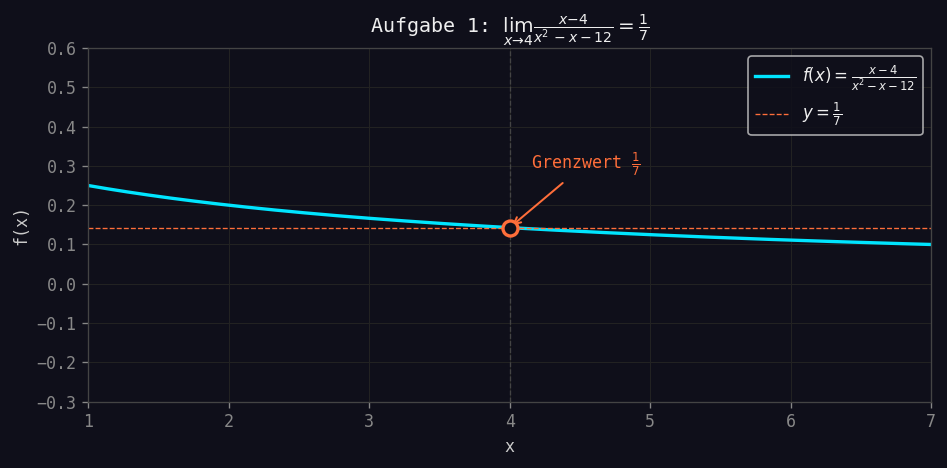

In [ ]:
#  Sympy-Verifikation
f1 = (x - 4) / (x**2 - x - 12)
lim1 = limit(f1, x, 4)
print(f'sympy bestätigt: lim = {lim1}  ({float(lim1):.6f})')

#  Plot 
fig, ax = plt.subplots(figsize=(8, 4))

x_vals = np.linspace(1, 7, 800)
# Singularität bei x=4 und x=-3 ausblenden
y_vals = np.where(np.abs(x_vals - 4) < 0.01, np.nan,
                  (x_vals - 4) / (x_vals**2 - x_vals - 12))

ax.plot(x_vals, y_vals, color=CYAN, lw=2, label=r'$f(x)=\frac{x-4}{x^2-x-12}$')
ax.axvline(4, color='#444', lw=0.8, ls='--')
ax.axhline(1/7, color=ORANGE, lw=0.8, ls='--', label=r'$y = \frac{1}{7}$')
annotate_limit(ax, 4, 1/7, r'Grenzwert $\frac{1}{7}$')
ax.set(xlim=(1, 7), ylim=(-0.3, 0.6),
       xlabel='x', ylabel='f(x)',
       title=r'Aufgabe 1: $\lim_{x\to 4}\frac{x-4}{x^2-x-12}=\frac{1}{7}$')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

---
## Aufgabe 2

$$\lim_{x \to -1} \frac{x^2+3x+2}{x^4+4x+3}$$

### Analytische Lösung

**Schritt 1 – Einsetzen prüfen:**  
Für $x=-1$: Zähler $= 1-3+2 = 0$, Nenner $= 1-4+3 = 0$ → **unbestimmter Ausdruck** $\tfrac{0}{0}$.

**Schritt 2 – Faktorisierung Zähler:**  
$$x^2 + 3x + 2 = (x+1)(x+2)$$

**Schritt 3 – Faktorisierung Nenner:**  
Man prüft: $(-1)^4 + 4(-1) + 3 = 0$, also ist $(x+1)$ ein Faktor.  
Polynomdivision oder Horner:  
$$x^4 + 4x + 3 \;\div\; (x+1) = x^3 - x^2 + x + 3$$
Dann prüft man $(-1)^3-(-1)^2+(-1)+3 = -1-1-1+3=0$, also noch ein Faktor $(x+1)$:  
$$x^3 - x^2 + x + 3 \;\div\; (x+1) = x^2 - 2x + 3$$
Somit:
$$x^4 + 4x + 3 = (x+1)^2\,(x^2 - 2x + 3)$$
Das verbleibende Quadrat $x^2-2x+3$ hat Diskriminante $4-12<0$ → **keine reellen Nullstellen**.

**Schritt 4 – Kürzen:**  
$$\frac{(x+1)(x+2)}{(x+1)^2(x^2-2x+3)} = \frac{x+2}{(x+1)(x^2-2x+3)}, \quad x \neq -1$$

**Schritt 5 – Verhalten nahe $x = -1$:**  
- Nenner $(x+1) \to 0$, $(x^2-2x+3)\big|_{x=-1} = 1+2+3 = 6 \neq 0$
- Zähler $(x+2)\big|_{x=-1} = 1 \neq 0$

Der Ausdruck divergiert. Vorzeichen prüfen:
- $x \to -1^+$: $(x+1)>0$ → $+\infty$  
- $x \to -1^-$: $(x+1)<0$ → $-\infty$

$$\lim_{x\to -1^+} = +\infty, \quad \lim_{x\to -1^-} = -\infty$$

Da links- und rechtsseitiger Grenzwert verschieden sind: **Der Grenzwert existiert nicht** (Polstelle erster Ordnung).

$$\boxed{\text{Grenzwert existiert nicht}}$$

Linksseitiger Grenzwert:  -oo
Rechtsseitiger Grenzwert: oo


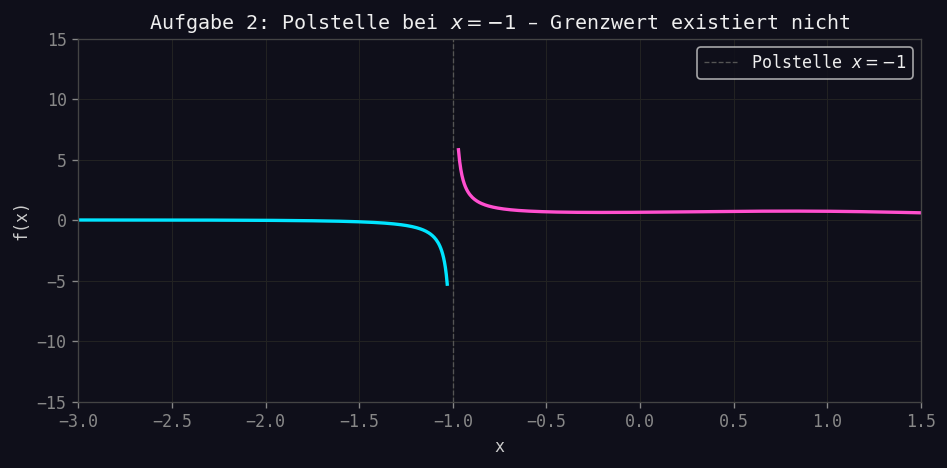

In [ ]:
#  Sympy-Verifikation
f2 = (x**2 + 3*x + 2) / (x**4 + 4*x + 3)
print(f'Linksseitiger Grenzwert:  {limit(f2, x, -1, "-")}')
print(f'Rechtsseitiger Grenzwert: {limit(f2, x, -1, "+")}')

#  Plot 
fig, ax = plt.subplots(figsize=(8, 4))

for seg, col in [(np.linspace(-3, -1.03, 400), CYAN),
                 (np.linspace(-0.97, 1.5, 400), PINK)]:
    y = (seg**2 + 3*seg + 2) / (seg**4 + 4*seg + 3)
    ax.plot(seg, y, color=col, lw=2)

ax.axvline(-1, color='#555', lw=0.8, ls='--', label='Polstelle $x=-1$')
ax.set(xlim=(-3, 1.5), ylim=(-15, 15),
       xlabel='x', ylabel='f(x)',
       title=r'Aufgabe 2: Polstelle bei $x=-1$ – Grenzwert existiert nicht')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

---
## Aufgabe 3

$$\lim_{x \to 1} \frac{x^4+2x^2-3}{x^2-3x+2}$$

### Analytische Lösung

**Schritt 1 – Einsetzen prüfen:**  
Für $x=1$: Zähler $= 1+2-3 = 0$, Nenner $= 1-3+2 = 0$ → $\tfrac{0}{0}$.

**Schritt 2 – Faktorisierung Zähler:**  
$x=1$ ist Nullstelle: $x^4+2x^2-3 = (x-1)(x^3+x^2+3x+3)$  
Der Restfaktor: $x^3+x^2+3x+3 = x^2(x+1)+3(x+1) = (x+1)(x^2+3)$  
$$\Rightarrow x^4+2x^2-3 = (x-1)(x+1)(x^2+3)$$

**Schritt 3 – Faktorisierung Nenner:**  
$$x^2-3x+2 = (x-1)(x-2)$$

**Schritt 4 – Kürzen:**  
$$\frac{(x-1)(x+1)(x^2+3)}{(x-1)(x-2)} = \frac{(x+1)(x^2+3)}{x-2}, \quad x\neq 1$$

**Schritt 5 – Grenzwert:**  
$$\lim_{x\to 1} \frac{(x+1)(x^2+3)}{x-2} = \frac{(1+1)(1+3)}{1-2} = \frac{2 \cdot 4}{-1} = \boxed{-8}$$

sympy bestätigt: lim = -8


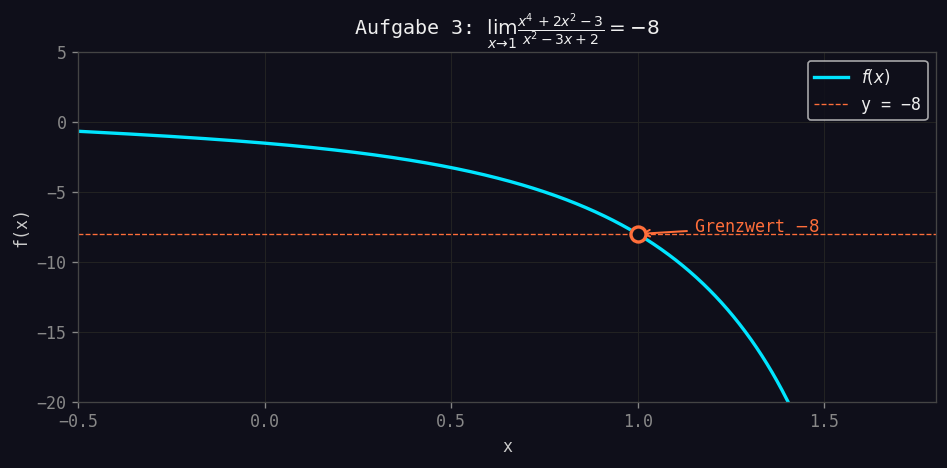

In [ ]:
#  Sympy-Verifikation
f3 = (x**4 + 2*x**2 - 3) / (x**2 - 3*x + 2)
lim3 = limit(f3, x, 1)
print(f'sympy bestätigt: lim = {lim3}')

#  Plot 
fig, ax = plt.subplots(figsize=(8, 4))

x_vals = np.linspace(-0.5, 1.8, 1000)
# Singularitäten bei x=1 und x=2 ausblenden
mask = (np.abs(x_vals - 1) < 0.02) | (np.abs(x_vals - 2) < 0.02)
y_vals = np.where(mask, np.nan,
                  (x_vals**4 + 2*x_vals**2 - 3) / (x_vals**2 - 3*x_vals + 2))

ax.plot(x_vals, y_vals, color=CYAN, lw=2, label=r'$f(x)$')
ax.axhline(-8, color=ORANGE, lw=0.8, ls='--', label='y = −8')
annotate_limit(ax, 1, -8, r'Grenzwert $-8$')
ax.set(xlim=(-0.5, 1.8), ylim=(-20, 5),
       xlabel='x', ylabel='f(x)',
       title=r'Aufgabe 3: $\lim_{x\to 1}\frac{x^4+2x^2-3}{x^2-3x+2}=-8$')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

---
## Aufgabe 4

$$\lim_{x \to 0^+} x^2 \log x$$

### Analytische Lösung

*(Hier wird $\log$ als natürlicher Logarithmus $\ln$ interpretiert; das Ergebnis ist dasselbe für jeden Logarithmus.)*

**Form:** $0 \cdot (-\infty)$ – unbestimmt. Umformen in $\tfrac{0}{0}$ oder $\tfrac{\infty}{\infty}$:

$$x^2 \ln x = \frac{\ln x}{x^{-2}}$$

Für $x\to 0^+$: Zähler $\to -\infty$, Nenner $\to +\infty$ → Form $\tfrac{-\infty}{+\infty}$.

**L'Hôpital anwenden** (beide Seiten ableiten):
$$\lim_{x\to 0^+} \frac{\ln x}{x^{-2}} \stackrel{\text{L'H}}{=} \lim_{x\to 0^+} \frac{\tfrac{1}{x}}{-2x^{-3}} = \lim_{x\to 0^+} \frac{1}{x} \cdot \frac{x^3}{-2} = \lim_{x\to 0^+} \frac{x^2}{-2} = \frac{0}{-2} = \boxed{0}$$

**Intuition:** Das polynomiale $x^2$ strebt schneller gegen 0 als $\ln x$ gegen $-\infty$.

$$\boxed{\lim_{x\to 0^+} x^2 \ln x = 0}$$

sympy bestätigt: lim = 0


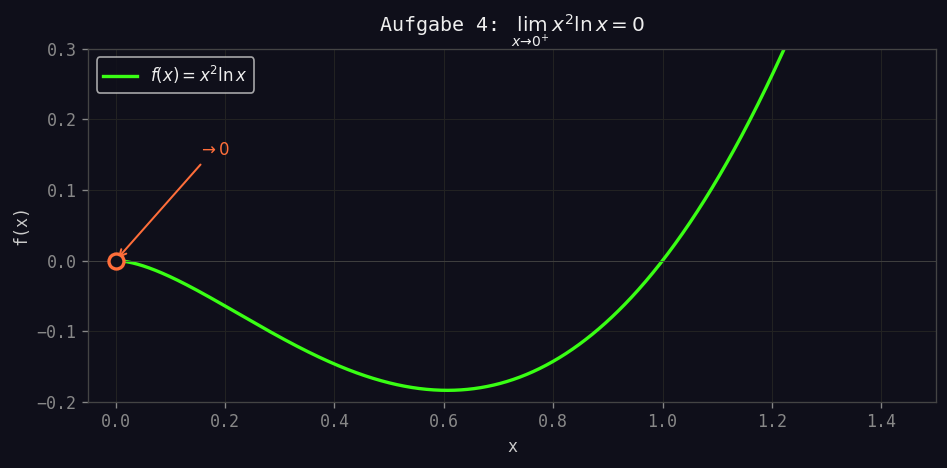

In [ ]:
#  Sympy-Verifikation
f4 = x**2 * log(x)
lim4 = limit(f4, x, 0, '+')
print(f'sympy bestätigt: lim = {lim4}')

#  Plot 
fig, ax = plt.subplots(figsize=(8, 4))

x_vals = np.linspace(0.001, 1.5, 1000)
y_vals = x_vals**2 * np.log(x_vals)

ax.plot(x_vals, y_vals, color=GREEN, lw=2, label=r'$f(x) = x^2 \ln x$')
ax.axhline(0, color='#444', lw=0.5)
annotate_limit(ax, 0, 0, r'$\to 0$', color=ORANGE)
ax.set(xlim=(-0.05, 1.5), ylim=(-0.2, 0.3),
       xlabel='x', ylabel='f(x)',
       title=r'Aufgabe 4: $\lim_{x\to 0^+} x^2\ln x = 0$')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

---
## Aufgabe 5

$$\lim_{x \to 0} \frac{\sin x}{x}$$

### Analytische Lösung – Regel von L'Hôpital

**Schritt 1 – Form prüfen:**  
Für $x = 0$: Zähler $\sin 0 = 0$, Nenner $= 0$ → unbestimmter Ausdruck $\tfrac{0}{0}$.

**Voraussetzung der Regel von L'Hôpital** ist erfüllt: beide Funktionen $g(x)=\sin x$ und $h(x)=x$ sind differenzierbar in einer Umgebung von $0$, und es liegt die Form $\tfrac{0}{0}$ vor.

**Schritt 2 – Zähler und Nenner separat ableiten:**
$$\frac{d}{dx}\sin x = \cos x, \qquad \frac{d}{dx}\,x = 1$$

**Schritt 3 – L'Hôpital anwenden:**
$$\lim_{x\to 0} \frac{\sin x}{x} \stackrel{\text{L'H}}{=} \lim_{x\to 0} \frac{\cos x}{1} = \cos(0) = 1$$

**Schritt 4 – Ergebnis:**
$$\boxed{\lim_{x \to 0} \frac{\sin x}{x} = 1}$$

sympy bestätigt: lim = 1


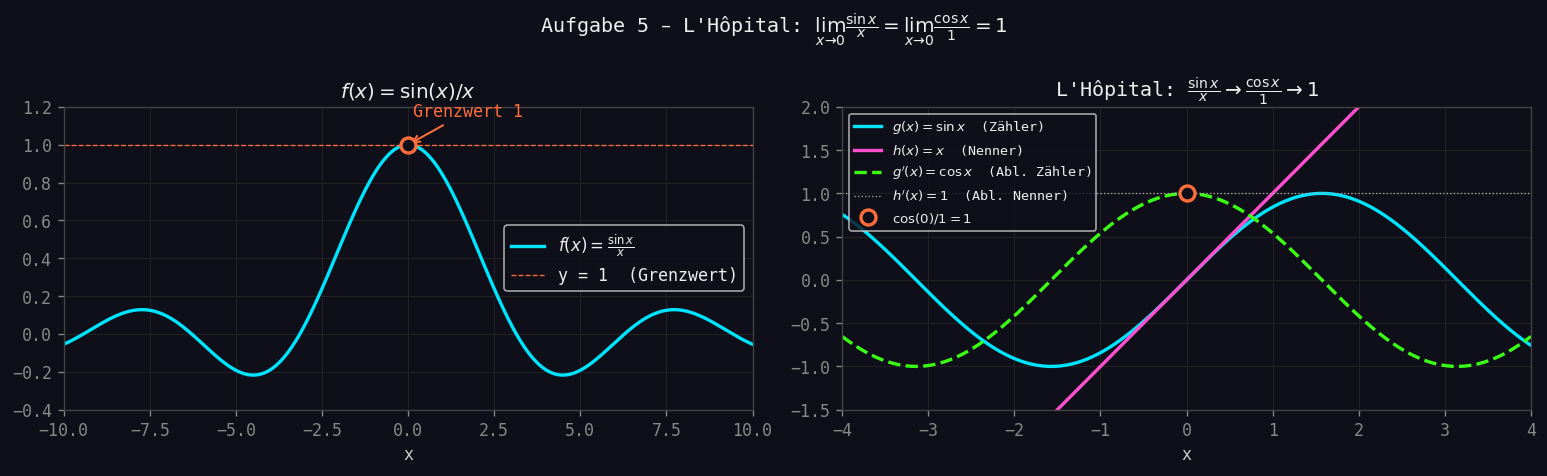

In [ ]:
#  Sympy-Verifikation
f5 = sin(x) / x
lim5 = limit(f5, x, 0)
print(f'sympy bestätigt: lim = {lim5}')

#  Plot: f(x) und Ableitung cos(x) – L'Hôpital-Visualisierung ─
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Links: f(x) = sin(x)/x mit Grenzwertpunkt
ax = axes[0]
x_vals = np.linspace(-10, 10, 2000)
y_vals = np.where(np.abs(x_vals) < 1e-9, 1.0, np.sin(x_vals) / x_vals)
ax.plot(x_vals, y_vals, color=CYAN, lw=2, label=r'$f(x)=\frac{\sin x}{x}$')
ax.axhline(1, color=ORANGE, lw=0.8, ls='--', label='y = 1  (Grenzwert)')
annotate_limit(ax, 0, 1, 'Grenzwert 1')
ax.set(xlim=(-10, 10), ylim=(-0.4, 1.2),
       xlabel='x', title=r'$f(x)=\sin(x)/x$')
ax.grid(True); ax.legend()

# Rechts: L'Hôpital – Zähler sin(x), Nenner x, und ihre Ableitungen
ax = axes[1]
x_lh = np.linspace(-4, 4, 600)
ax.plot(x_lh, np.sin(x_lh),      color=CYAN,  lw=2,        label=r"$g(x)=\sin x$  (Zähler)")
ax.plot(x_lh, x_lh,              color=PINK,  lw=2,        label=r"$h(x)=x$  (Nenner)")
ax.plot(x_lh, np.cos(x_lh),      color=GREEN, lw=2, ls='--', label=r"$g'(x)=\cos x$  (Abl. Zähler)")
ax.axhline(1,                     color='#aaa', lw=0.8, ls=':', label=r"$h'(x)=1$  (Abl. Nenner)")
ax.plot(0, 1, 'o', markersize=9, color=ORANGE,
        markerfacecolor='#0f0f1a', markeredgewidth=2,
        label=r"$\cos(0)/1 = 1$")
ax.set(xlim=(-4, 4), ylim=(-1.5, 2),
       xlabel='x',
       title=r"L'Hôpital: $\frac{\sin x}{x}\to\frac{\cos x}{1}\to 1$")
ax.grid(True); ax.legend(fontsize=8)

fig.suptitle(r"Aufgabe 5 – L'Hôpital: $\lim_{x\to 0}\frac{\sin x}{x}=\lim_{x\to 0}\frac{\cos x}{1}=1$", fontsize=12)
plt.tight_layout()
plt.show()

---
## Aufgabe 6

$$\lim_{x \to 0^+} x^{x^2}$$

### Analytische Lösung

**Form:** $0^0$ – unbestimmt. Strategie: Exponentialform + L'Hôpital.

**Schritt 1 – Logarithmieren:**  
$$\ln\!\left(x^{x^2}\right) = x^2 \ln x$$

**Schritt 2 – Grenzwert des Logarithmus:**  
Von **Aufgabe 4** wissen wir bereits:  
$$\lim_{x\to 0^+} x^2 \ln x = 0$$

**Schritt 3 – Rücktransformation:**  
Da $\exp$ stetig ist:
$$\lim_{x\to 0^+} x^{x^2} = \exp\!\left(\lim_{x\to 0^+} x^2 \ln x\right) = e^0 = \boxed{1}$$

sympy bestätigt: lim = 1


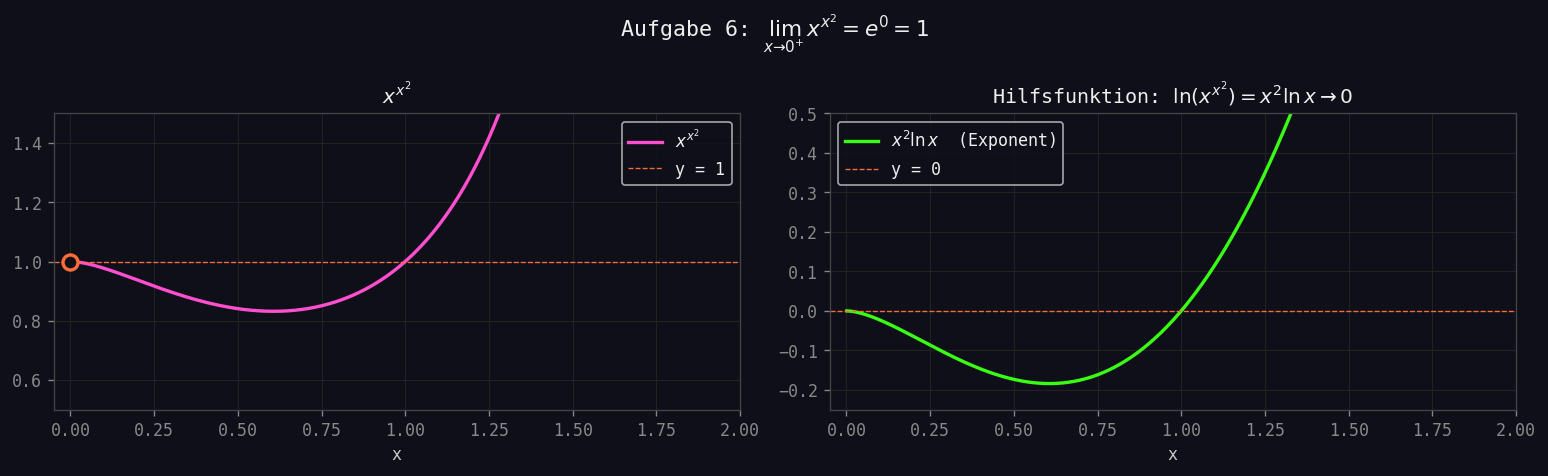

In [ ]:
#  Sympy-Verifikation
f6 = x**(x**2)
lim6 = limit(f6, x, 0, '+')
print(f'sympy bestätigt: lim = {lim6}')

#  Plot 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x_vals = np.linspace(0.001, 2, 800)

# Linke Seite: x^(x²)
ax = axes[0]
y_main = x_vals ** (x_vals**2)
ax.plot(x_vals, y_main, color=PINK, lw=2, label=r'$x^{x^2}$')
ax.axhline(1, color=ORANGE, lw=0.8, ls='--', label='y = 1')
ax.plot(0, 1, 'o', markersize=9, color=ORANGE, markerfacecolor='#0f0f1a', markeredgewidth=2)
ax.set(xlim=(-0.05, 2), ylim=(0.5, 1.5),
       xlabel='x', title=r'$x^{x^2}$')
ax.grid(True); ax.legend()

# Rechte Seite: Hilfsfunktion x²·ln(x)
ax = axes[1]
y_log = x_vals**2 * np.log(x_vals)
ax.plot(x_vals, y_log, color=GREEN, lw=2, label=r'$x^2\ln x$  (Exponent)')
ax.axhline(0, color=ORANGE, lw=0.8, ls='--', label='y = 0')
ax.set(xlim=(-0.05, 2), ylim=(-0.25, 0.5),
       xlabel='x', title=r'Hilfsfunktion: $\ln(x^{x^2}) = x^2\ln x \to 0$')
ax.grid(True); ax.legend()

fig.suptitle(r'Aufgabe 6: $\lim_{x\to 0^+} x^{x^2}=e^0=1$', fontsize=13)
plt.tight_layout()
plt.show()

---
## Aufgabe 7

$$\lim_{x \to \infty} \bigl(\log(x+1) - \log x\bigr)$$

### Analytische Lösung

**Form:** $\infty - \infty$ – unbestimmt. Mit dem Logarithmengesetz $\log a - \log b = \log\tfrac{a}{b}$:

$$\log(x+1) - \log x = \log\!\left(\frac{x+1}{x}\right) = \log\!\left(1 + \frac{1}{x}\right)$$

Für $x \to \infty$ gilt $\frac{1}{x} \to 0$, also:
$$\lim_{x\to\infty} \log\!\left(1 + \frac{1}{x}\right) = \log(1 + 0) = \log 1 = \boxed{0}$$

*(Das Argument des Logarithmus konvergiert gegen 1, und $\log$ ist stetig.)*

**Alternativ mit dem bekannten Limit:**  
$$\left(1+\frac{1}{x}\right)^x \xrightarrow{x\to\infty} e \implies \log\!\left(1+\frac{1}{x}\right) \approx \frac{1}{x} \to 0$$

sympy bestätigt: lim = 0


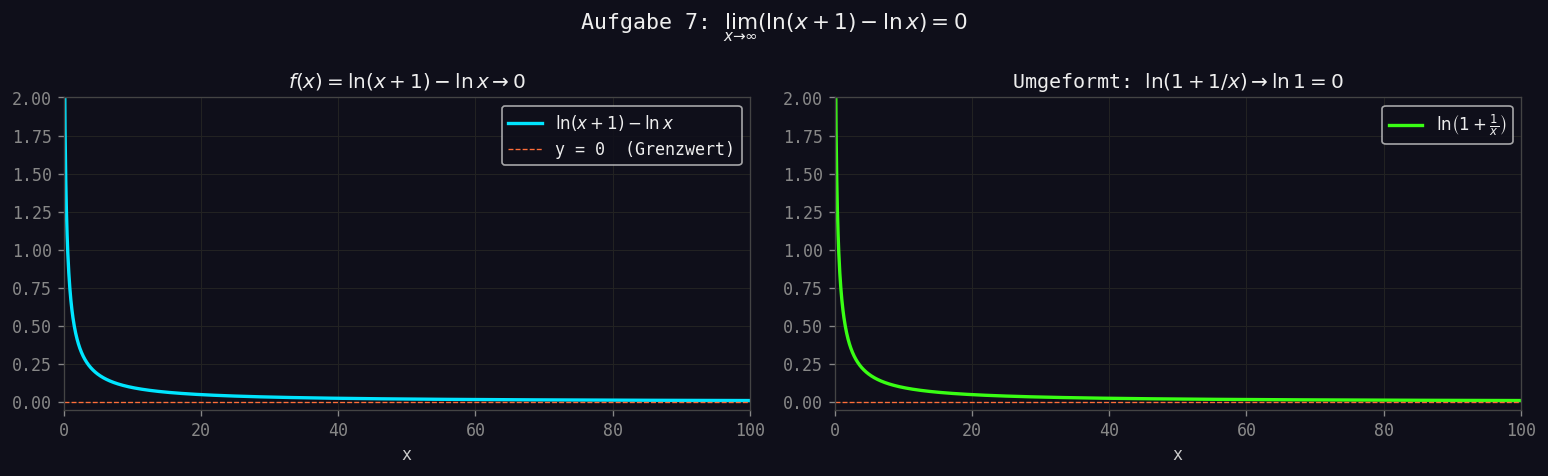

In [ ]:
#  Sympy-Verifikation 
f7 = log(x + 1) - log(x)
lim7 = limit(f7, x, oo)
print(f'sympy bestätigt: lim = {lim7}')

#  Plot 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x_vals = np.linspace(0.1, 100, 2000)

ax = axes[0]
y7 = np.log(x_vals + 1) - np.log(x_vals)
ax.plot(x_vals, y7, color=CYAN, lw=2, label=r'$\ln(x+1)-\ln x$')
ax.axhline(0, color=ORANGE, lw=0.8, ls='--', label='y = 0  (Grenzwert)')
ax.set(xlim=(0, 100), ylim=(-0.05, 2),
       xlabel='x', title=r'$f(x)=\ln(x+1)-\ln x \to 0$')
ax.grid(True); ax.legend()

ax = axes[1]
y7b = np.log(1 + 1/x_vals)
ax.plot(x_vals, y7b, color=GREEN, lw=2, label=r'$\ln\!\left(1+\frac{1}{x}\right)$')
ax.axhline(0, color=ORANGE, lw=0.8, ls='--')
ax.set(xlim=(0, 100), ylim=(-0.05, 2),
       xlabel='x', title=r'Umgeformt: $\ln(1+1/x)\to\ln 1=0$')
ax.grid(True); ax.legend()

fig.suptitle(r'Aufgabe 7: $\lim_{x\to\infty}(\ln(x+1)-\ln x)=0$', fontsize=13)
plt.tight_layout()
plt.show()

---
## Aufgabe 8

$$\lim_{x \to 0^+} (\sin x)^x$$

### Analytische Lösung

**Form:** $0^0$ – unbestimmt. Strategie: Exponentialform + L'Hôpital.

**Schritt 1 – Logarithmieren:**  
$$\ln\!\bigl((\sin x)^x\bigr) = x\ln(\sin x)$$

**Schritt 2 – Umformen in $\frac{\infty}{\infty}$:**  
$$x\ln(\sin x) = \frac{\ln(\sin x)}{1/x}$$

Für $x\to 0^+$: Zähler $\to -\infty$, Nenner $\to +\infty$. **L'Hôpital:**
$$\lim_{x\to 0^+} \frac{\ln(\sin x)}{1/x} \stackrel{\text{L'H}}{=} \lim_{x\to 0^+} \frac{\frac{\cos x}{\sin x}}{-1/x^2} = \lim_{x\to 0^+} \frac{-x^2 \cos x}{\sin x}$$

**Schritt 3 – Bekanntes Limit verwenden:**  
$$= \lim_{x\to 0^+} \left(-x \cdot \cos x \cdot \frac{x}{\sin x}\right) = (-0) \cdot 1 \cdot 1 = 0$$

Hierbei: $x\to 0$, $\cos 0 = 1$, $\lim_{x\to 0}\frac{x}{\sin x} = 1$ (Kehrwert von Aufgabe 5).

**Schritt 4 – Rücktransformation:**  
$$\lim_{x\to 0^+} (\sin x)^x = e^0 = \boxed{1}$$

sympy bestätigt: lim = 1


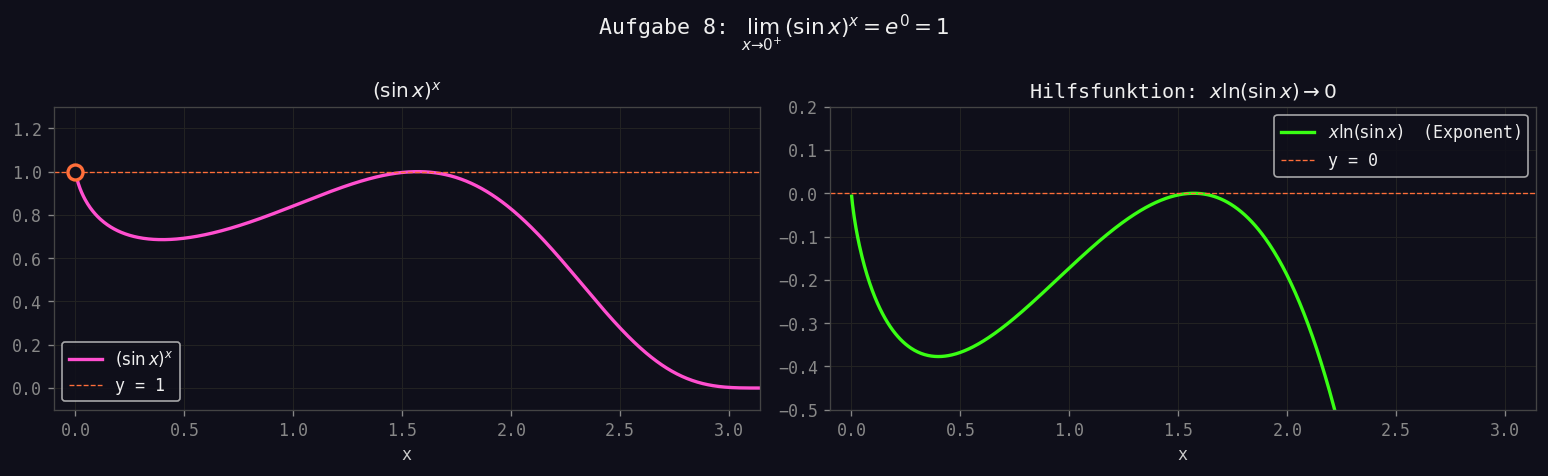

In [ ]:
#  Sympy-Verifikation
f8 = sin(x)**x
lim8 = limit(f8, x, 0, '+')
print(f'sympy bestätigt: lim = {lim8}')

#  Plot 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x_vals = np.linspace(0.001, np.pi, 800)

ax = axes[0]
y8 = np.sin(x_vals) ** x_vals
ax.plot(x_vals, y8, color=PINK, lw=2, label=r'$(\sin x)^x$')
ax.axhline(1, color=ORANGE, lw=0.8, ls='--', label='y = 1')
ax.plot(0, 1, 'o', markersize=9, color=ORANGE, markerfacecolor='#0f0f1a', markeredgewidth=2)
ax.set(xlim=(-0.1, np.pi), ylim=(-0.1, 1.3),
       xlabel='x', title=r'$(\sin x)^x$')
ax.grid(True); ax.legend()

# Hilfsfunktion: x·ln(sin x)
ax = axes[1]
x_h = np.linspace(0.001, np.pi, 800)
y_h = x_h * np.log(np.sin(x_h))
ax.plot(x_h, y_h, color=GREEN, lw=2, label=r'$x\ln(\sin x)$  (Exponent)')
ax.axhline(0, color=ORANGE, lw=0.8, ls='--', label='y = 0')
ax.set(xlim=(-0.1, np.pi), ylim=(-0.5, 0.2),
       xlabel='x', title=r'Hilfsfunktion: $x\ln(\sin x)\to 0$')
ax.grid(True); ax.legend()

fig.suptitle(r'Aufgabe 8: $\lim_{x\to 0^+}(\sin x)^x = e^0 = 1$', fontsize=13)
plt.tight_layout()
plt.show()